## Admission prediction

In [73]:
from sklearn.model_selection import train_test_split
import pandas as pd

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

import joblib

## Load dataset

In [3]:
df=pd.read_csv("Admission_Predict.csv")  
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


## Preprocessing

In [4]:
df.shape

(400, 9)

In [5]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [6]:
df.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [8]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [9]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [10]:
df.drop(columns=["Serial No."], inplace=True, errors='ignore')

In [11]:
df[["CGPA", "Chance of Admit "]].corr()

,CGPA,Chance of Admit
CGPA,1.000000,0.873289
Chance of Admit,0.873289,1.000000


In [12]:
df["Admit"]=(df["Chance of Admit "] >= 0.82).astype(int)

In [13]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Admit
0,337,118,4,4.5,4.5,9.65,1,0.92,1
1,324,107,4,4.0,4.5,8.87,1,0.76,0
2,316,104,3,3.0,3.5,8.00,1,0.72,0
3,322,110,3,3.5,2.5,8.67,1,0.80,0
4,314,103,2,2.0,3.0,8.21,0,0.65,0
...,...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82,1
396,325,107,3,3.0,3.5,9.11,1,0.84,1
397,330,116,4,5.0,4.5,9.45,1,0.91,1
398,312,103,3,3.5,4.0,8.78,0,0.67,0


In [14]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit ', 'Admit'],
      dtype='object')

In [15]:
df.drop(columns=["Chance of Admit "], inplace=True)

In [16]:
x=df[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research']]
y=df["Admit"]

In [18]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [19]:
print("x columns:", x.columns.tolist())
print("Contains Chance of Admit?", any("chance" in c.lower() for c in x.columns))
print("Contains Admit?", any("admit" in c.lower() for c in x.columns))

x columns: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
Contains Chance of Admit? False
Contains Admit? False


In [20]:
y

0      1
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Admit, Length: 400, dtype: int64

## EDA

In [21]:
## roc and auc

<Axes: >

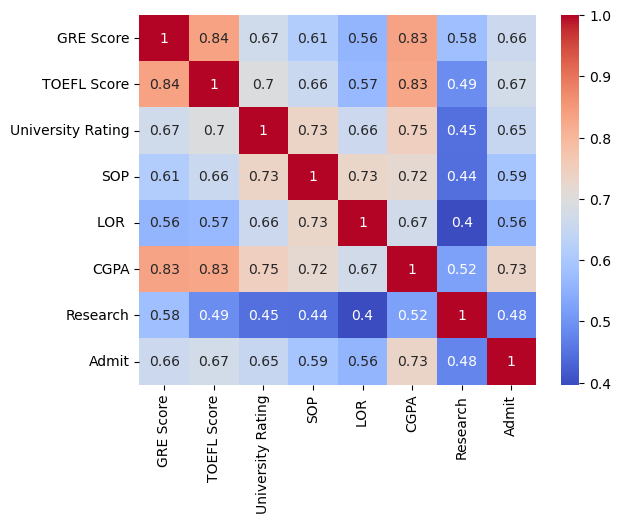

In [22]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

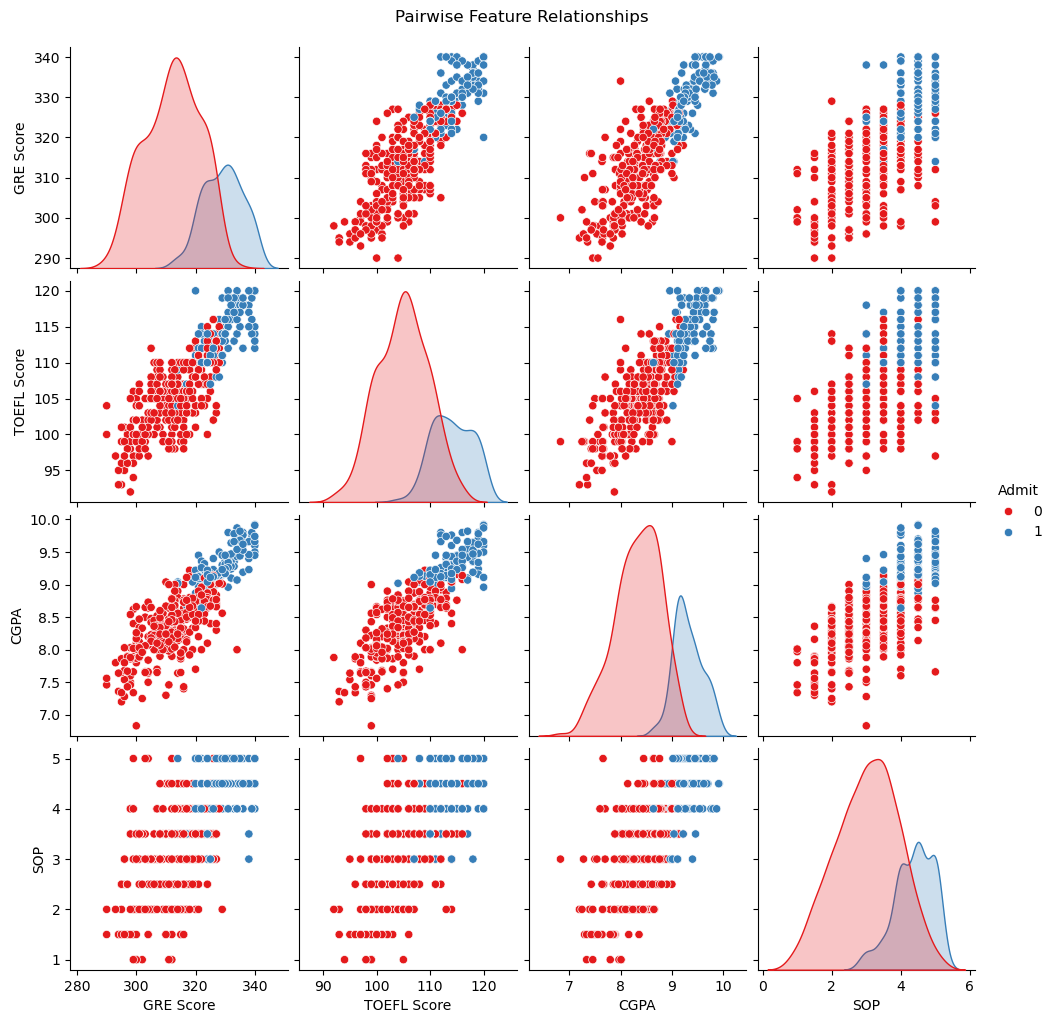

In [59]:
sns.pairplot(df, vars=["GRE Score","TOEFL Score","CGPA","SOP"], hue="Admit", palette="Set1")
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

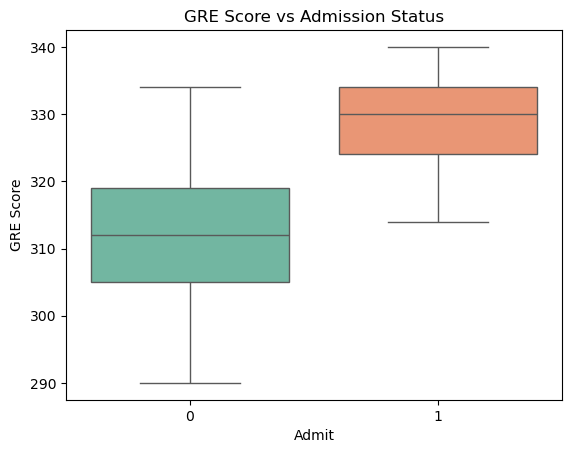

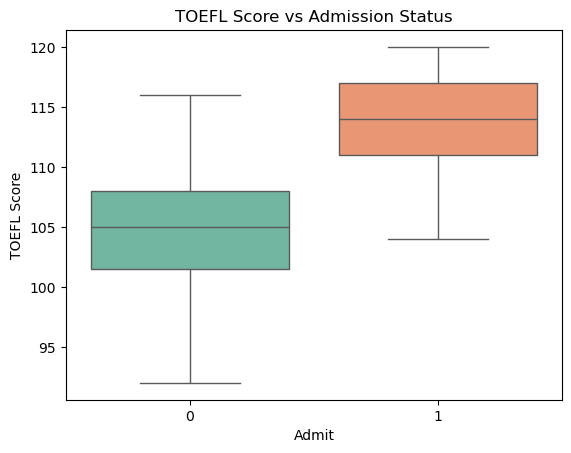

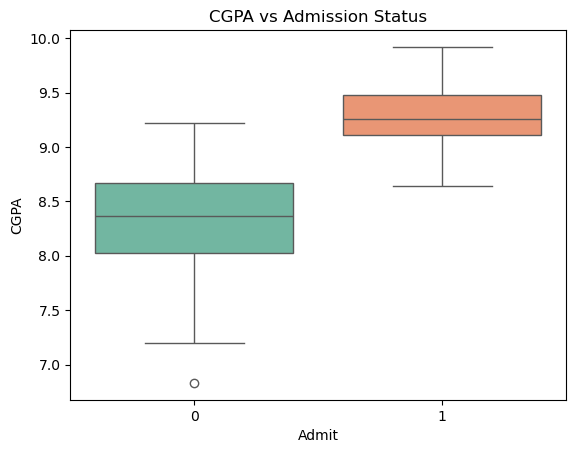

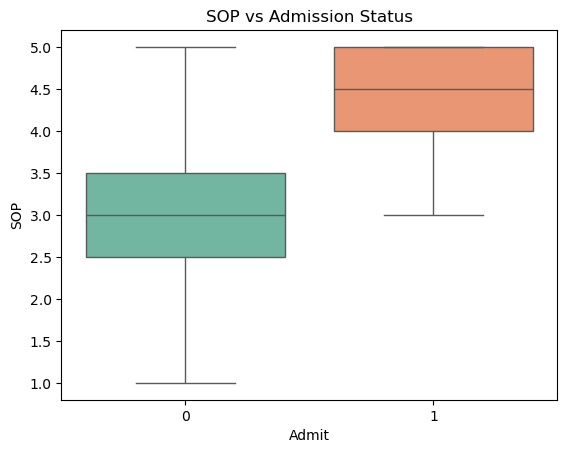

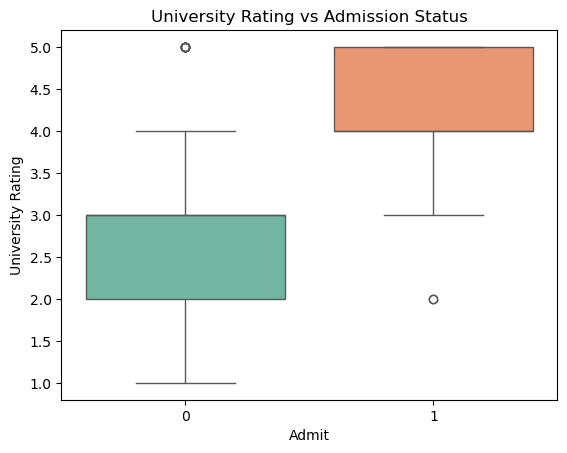

In [63]:
features = ["GRE Score","TOEFL Score","CGPA","SOP","University Rating"]
for f in features:
    sns.boxplot(x="Admit", y=f, data=df, palette="Set2")
    plt.title(f"{f} vs Admission Status")
    plt.show()

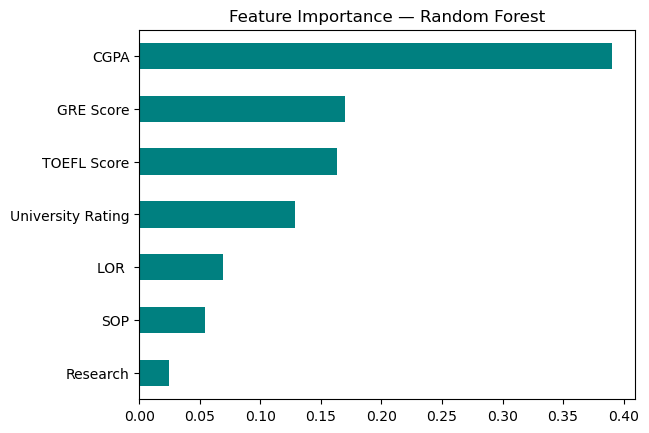

In [69]:
feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values()
feat_imp.plot(kind="barh", color="teal")
plt.title("Feature Importance — Random Forest")
plt.show()

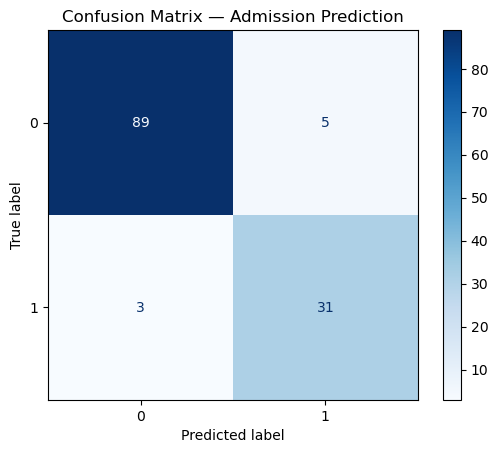

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — Admission Prediction")
plt.show()

## Train Test Split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.32,random_state=32)
print(x_train.shape, x_test.shape)
print("Overlap?", len(set(x_train.index) & set(x_test.index)) > 0)

(272, 7) (128, 7)
Overlap? False


## Outlier Treatment

<Axes: >

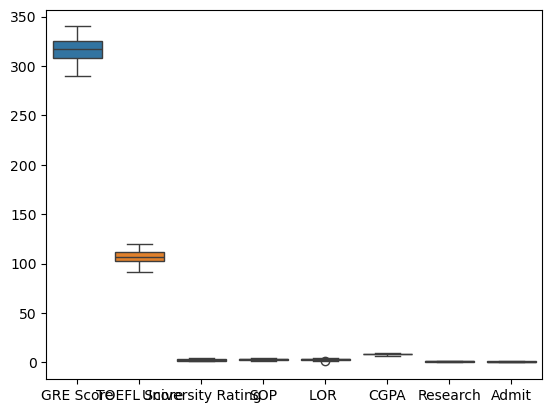

In [58]:
lst=["GRE Score","TOEFL Score","University Rating","SOP","CGPA","Research"]
for i in lst:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  df.loc[(df[i]>=upper_limit),i]=upper_limit
  df.loc[(df[i]<=lower_limit),i]=lower_limit
sns.boxplot(df)

## Models

## KNN

Test accuracy: 0.9296875
train accuracy: 0.9522058823529411
CR:               precision    recall  f1-score   support

           0       0.95      0.96      0.95        94
           1       0.88      0.85      0.87        34

    accuracy                           0.93       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.93      0.93      0.93       128



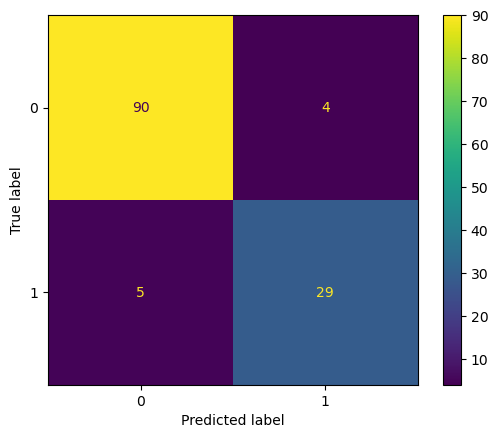

In [24]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
kc=accuracy_score(y_test,y_pred)*100

## Logistic Regression

Test accuracy: 0.9296875
train accuracy: 0.9117647058823529
CR:               precision    recall  f1-score   support

           0       0.95      0.96      0.95        94
           1       0.88      0.85      0.87        34

    accuracy                           0.93       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.93      0.93      0.93       128



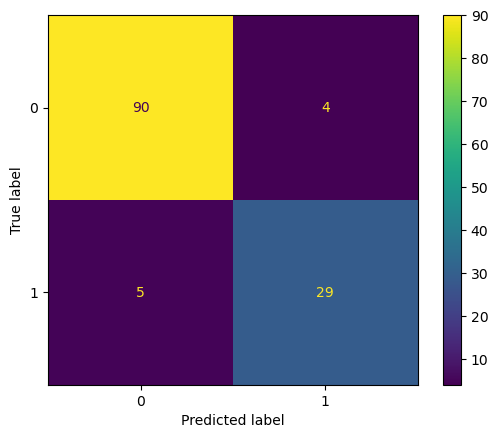

In [25]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
print('Test accuracy:',lr.score(x_test,y_test))
print('train accuracy:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
lra=accuracy_score(y_test,y_pred)*100

## Naive Bayes

Test accuracy: 0.9140625
train accuracy: 0.9191176470588235
CR:               precision    recall  f1-score   support

           0       0.96      0.93      0.94        94
           1       0.81      0.88      0.85        34

    accuracy                           0.91       128
   macro avg       0.88      0.90      0.89       128
weighted avg       0.92      0.91      0.92       128



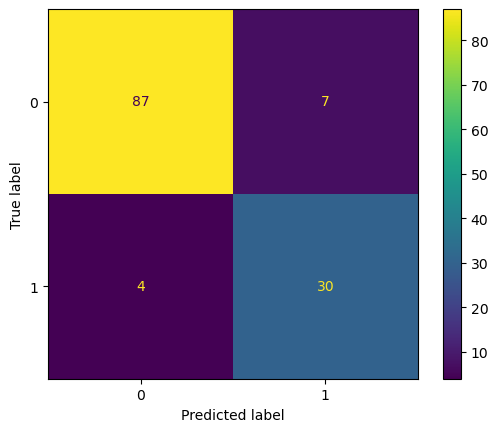

In [26]:
gb=GaussianNB()
gb.fit(x_train,y_train)
y_preds=gb.predict(x_test)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
nb=accuracy_score(y_test,y_preds)*100

## Random Forest

Test accuracy: 0.9375
train accuracy: 0.9889705882352942
CR:               precision    recall  f1-score   support

           0       0.96      0.96      0.96        94
           1       0.88      0.88      0.88        34

    accuracy                           0.94       128
   macro avg       0.92      0.92      0.92       128
weighted avg       0.94      0.94      0.94       128



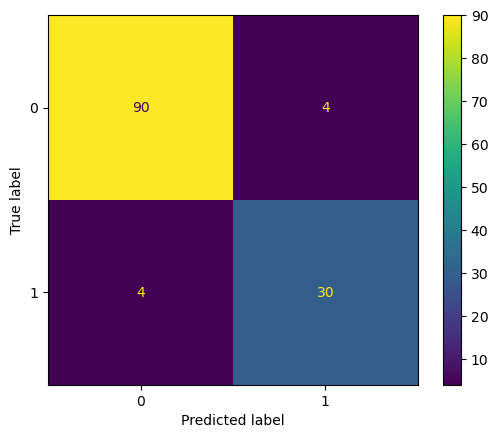

In [27]:
rf=RandomForestClassifier(n_estimators=5,random_state=10)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
rfa=accuracy_score(y_test,y_pred)*100

## Adaboost

Test accuracy: 0.921875
train accuracy: 0.9411764705882353
CR:               precision    recall  f1-score   support

           0       0.98      0.91      0.95        94
           1       0.80      0.94      0.86        34

    accuracy                           0.92       128
   macro avg       0.89      0.93      0.90       128
weighted avg       0.93      0.92      0.92       128



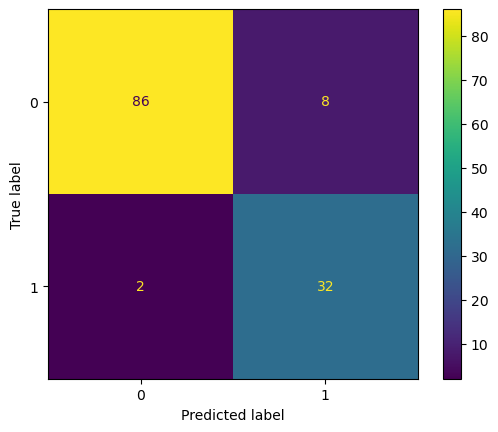

In [28]:
adaboost=AdaBoostClassifier(n_estimators=10,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_pred=adaboost.predict(x_test)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
ac=accuracy_score(y_test,y_pred)*100

## Gradient Boosting

Test accuracy: 0.9296875
train accuracy: 0.9926470588235294
CR:               precision    recall  f1-score   support

           0       0.96      0.95      0.95        94
           1       0.86      0.88      0.87        34

    accuracy                           0.93       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.93      0.93      0.93       128



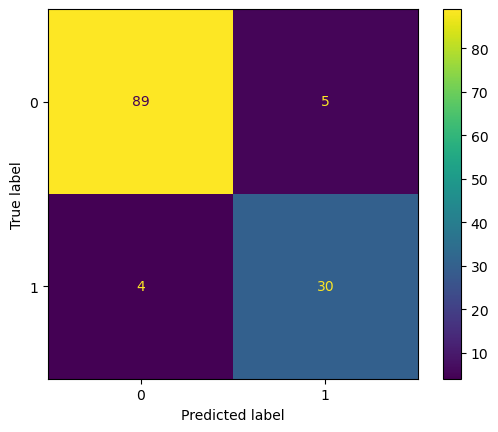

In [29]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_preds=gbc.predict(x_test)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
gbca=accuracy_score(y_test,y_preds)*100

## Decision Tree

Test accuracy: 0.921875
train accuracy: 1.0
CR:               precision    recall  f1-score   support

           0       0.95      0.95      0.95        94
           1       0.85      0.85      0.85        34

    accuracy                           0.92       128
   macro avg       0.90      0.90      0.90       128
weighted avg       0.92      0.92      0.92       128



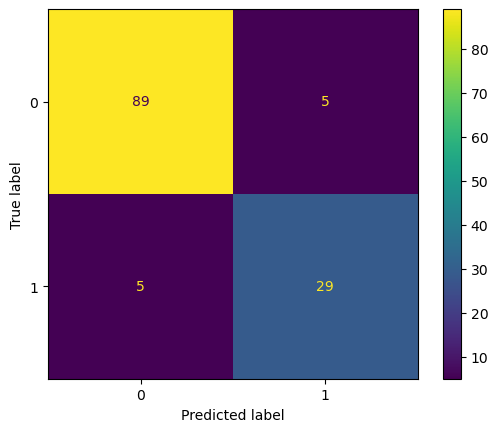

In [30]:
dt=DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
y_predd=dt.predict(x_test)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_predd))
print('CR:',classification_report(y_test,y_predd))
dta=accuracy_score(y_test,y_predd)*100

In [31]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt'])
tb['accuracy']=pd.Series([kc,lra,nb,rfa,ac,gbca,dta])
tb

,model,accuracy
0,knn,92.96875
1,lr,92.96875
2,gb,91.40625
3,rf,93.75000
4,adaboost,92.18750
5,gbc,92.96875
6,dt,92.18750


In [32]:
df.value_counts('Admit')

Admit
0    291
1    109
Name: count, dtype: int64

## Oversampling

In [583]:
ros=RandomOverSampler(random_state=42) 
x_res,y_res=ros.fit_resample(x,y)
print('Resampled dataset shape:', Counter(y_res))

Resampled dataset shape: Counter({1: 291, 0: 291})


In [584]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_ov,y_ov,test_size=0.3,random_state=32)

Test accuracy: 0.9085365853658537
train accuracy: 0.9421052631578948
CR:               precision    recall  f1-score   support

           0       0.93      0.90      0.91        86
           1       0.89      0.92      0.91        78

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164



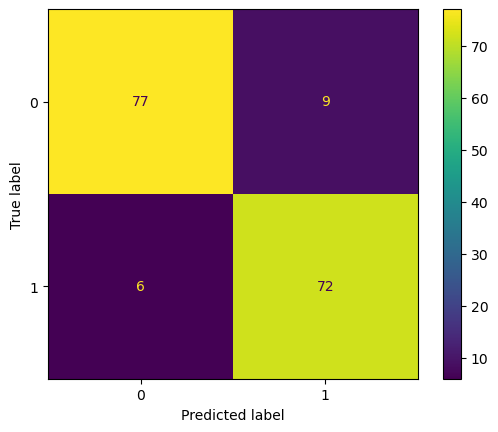

In [585]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
koc=accuracy_score(y_test,y_pred)*100

Test accuracy: 0.9146341463414634
train accuracy: 0.9131578947368421
CR:               precision    recall  f1-score   support

           0       0.93      0.90      0.91        86
           1       0.89      0.92      0.91        78

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164



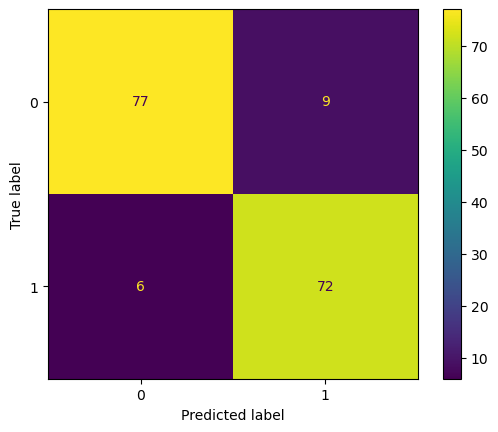

In [586]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
print('Test accuracy:',lr.score(x_test,y_test))
print('train accuracy:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
lro=accuracy_score(y_test,y_pred)*100

Test accuracy: 0.9146341463414634
train accuracy: 0.9157894736842105
CR:               precision    recall  f1-score   support

           0       0.89      0.95      0.92        86
           1       0.94      0.87      0.91        78

    accuracy                           0.91       164
   macro avg       0.92      0.91      0.91       164
weighted avg       0.92      0.91      0.91       164



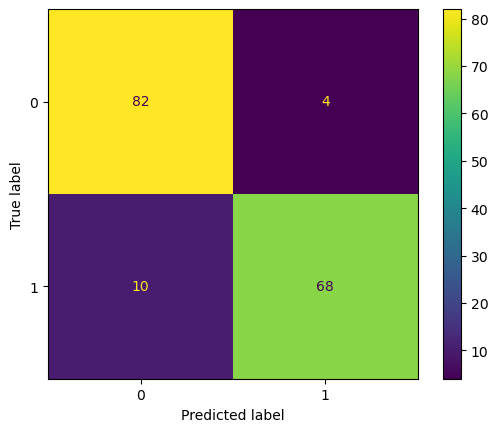

In [587]:
gb=GaussianNB()
gb.fit(x_train,y_train)
y_preds=gb.predict(x_test)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
nbo=accuracy_score(y_test,y_preds)*100

Test accuracy: 0.9329268292682927
train accuracy: 0.9868421052631579
CR:               precision    recall  f1-score   support

           0       0.93      0.94      0.94        86
           1       0.94      0.92      0.93        78

    accuracy                           0.93       164
   macro avg       0.93      0.93      0.93       164
weighted avg       0.93      0.93      0.93       164



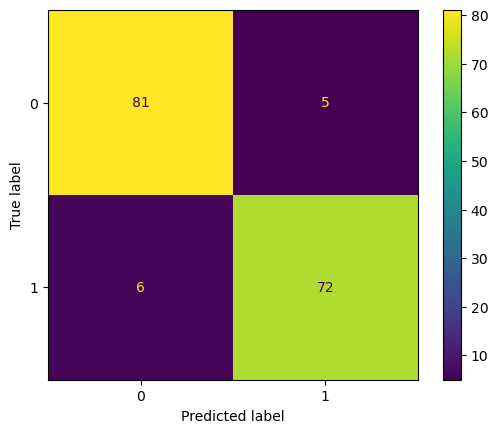

In [588]:
rf=RandomForestClassifier(n_estimators=5,random_state=10)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
rfo=accuracy_score(y_test,y_pred)*100

Test accuracy: 0.9146341463414634
train accuracy: 0.9184210526315789
CR:               precision    recall  f1-score   support

           0       0.92      0.92      0.92        86
           1       0.91      0.91      0.91        78

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164



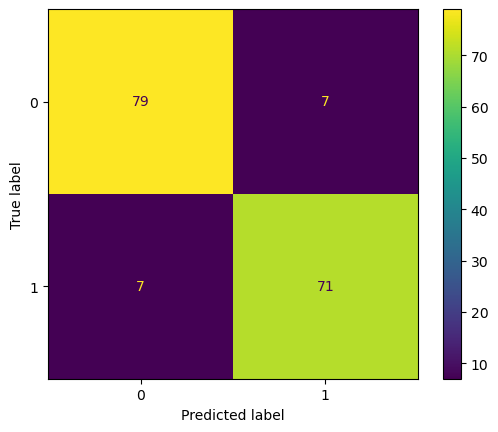

In [589]:
adaboost=AdaBoostClassifier(n_estimators=10,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_pred=adaboost.predict(x_test)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
ao=accuracy_score(y_test,y_pred)*100

Test accuracy: 0.926829268292683
train accuracy: 0.9763157894736842
CR:               precision    recall  f1-score   support

           0       0.93      0.93      0.93        86
           1       0.92      0.92      0.92        78

    accuracy                           0.93       164
   macro avg       0.93      0.93      0.93       164
weighted avg       0.93      0.93      0.93       164



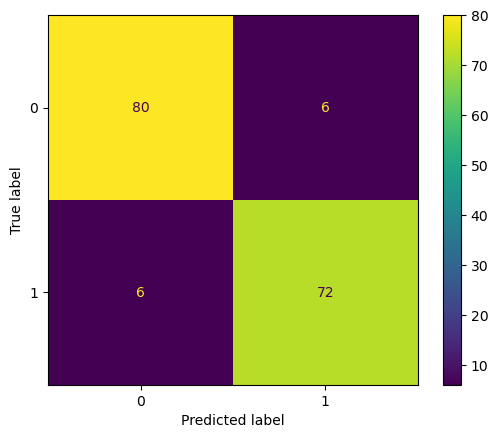

In [590]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_preds=gbc.predict(x_test)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
gbco=accuracy_score(y_test,y_preds)*100

Test accuracy: 0.9146341463414634
train accuracy: 1.0
CR:               precision    recall  f1-score   support

           0       0.93      0.91      0.92        86
           1       0.90      0.92      0.91        78

    accuracy                           0.91       164
   macro avg       0.91      0.92      0.91       164
weighted avg       0.91      0.91      0.91       164



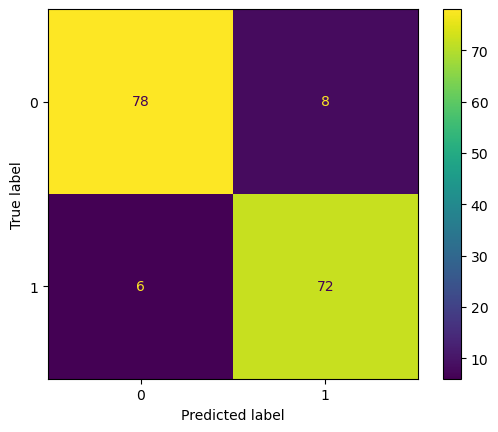

In [591]:
dt=DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
y_predd=dt.predict(x_test)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_predd))
print('CR:',classification_report(y_test,y_predd))
dto=accuracy_score(y_test,y_predd)*100

## After Oversampling

In [592]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt'])
tb['accuracy']=pd.Series([kc,lra,nb,rfa,ac,gbca,dta])
tb['Accuracy_oversampling']=pd.Series([koc,lro,nbo,rfo,ao,gbco,dto])
tb

,model,accuracy,Accuracy_oversampling
0,knn,92.96875,90.853659
1,lr,92.96875,90.853659
2,gb,91.40625,91.463415
3,rf,93.75000,93.292683
4,adaboost,92.18750,91.463415
5,gbc,92.96875,92.682927
6,dt,91.40625,91.463415


## Cross Validation

In [50]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
scores = cross_val_score(rf, x, y, cv=5, scoring='accuracy')
print("Cross-val accuracy:", scores.mean()*100, "±", scores.std()*100)


Cross-val accuracy: 93.24999999999999 ± 2.3184046238739264


In [51]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced_subsample", random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.8, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, random_state=42)
}

# Cross-validation setup (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV for each model
for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=cv, scoring='accuracy')
    print(f"{name:20s} | Mean CV Acc: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

KNN                  | Mean CV Acc: 91.75% ± 2.57%
LogisticRegression   | Mean CV Acc: 93.25% ± 4.23%
GradientBoosting     | Mean CV Acc: 93.50% ± 4.57%
RandomForest         | Mean CV Acc: 94.00% ± 4.36%
AdaBoost             | Mean CV Acc: 93.00% ± 3.76%
DecisionTree         | Mean CV Acc: 91.25% ± 4.81%


## HyperParameter Tuning

In [33]:
par={'n_neighbors':[3,5,27,59,11],'weights':['uniform','distance'],'algorithm':['auto','ball_tree','kd_tree']}
knt=GridSearchCV(knn,par,cv=10,scoring='accuracy')
knt.fit(x_train,y_train)
print(knt.best_params_)

{'algorithm': 'auto', 'n_neighbors': 11, 'weights': 'uniform'}


Test accuracy: 0.9609375
train accuracy: 0.9411764705882353
CR:               precision    recall  f1-score   support

           0       0.97      0.98      0.97        94
           1       0.94      0.91      0.93        34

    accuracy                           0.96       128
   macro avg       0.95      0.95      0.95       128
weighted avg       0.96      0.96      0.96       128



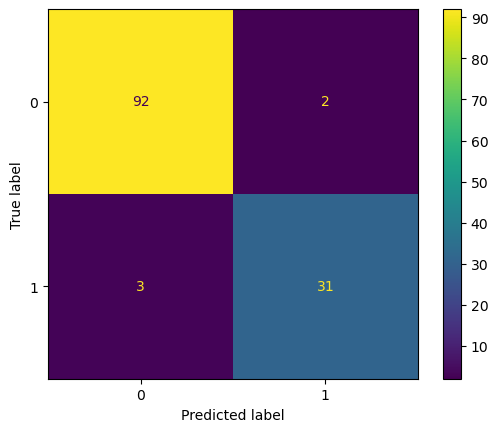

In [34]:
knn=KNeighborsClassifier(n_neighbors=5,algorithm='auto',weights='uniform')
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
knt=accuracy_score(y_test,y_pred)*100
y_tpred=knn.predict(x_train)
kntt=accuracy_score(y_tpred,y_train)*100

In [35]:
par={'C':[0.1,1,10,100],'penalty':['l1','l2'],'solver':['liblinear','lbfgs','saga']}
lrt=GridSearchCV(lr,par,cv=10,scoring='accuracy')
lrt.fit(x_train,y_train)
print(lrt.best_params_)

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}


Test accuracy: 0.9375
train accuracy: 0.9522058823529411
CR:               precision    recall  f1-score   support

           0       0.97      0.98      0.97        94
           1       0.94      0.91      0.93        34

    accuracy                           0.96       128
   macro avg       0.95      0.95      0.95       128
weighted avg       0.96      0.96      0.96       128



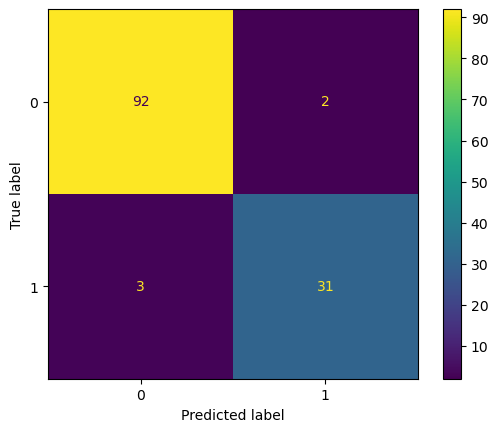

In [36]:
lr=LogisticRegression(C=100,penalty='l2',solver='liblinear')
lr.fit(x_train,y_train)
print('Test accuracy:',lr.score(x_test,y_test))
print('train accuracy:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
lrt=accuracy_score(y_test,y_pred)*100
y_tpred1=lr.predict(x_train)
lrtt=accuracy_score(y_tpred1,y_train)*100

In [37]:
par={'var_smoothing':[1e-9,1e-8,1e-7]}
nbt=GridSearchCV(gb,par,cv=10,scoring='accuracy')
nbt.fit(x_train,y_train)
print(nbt.best_params_)

{'var_smoothing': 1e-09}


Test accuracy: 0.9140625
train accuracy: 0.9191176470588235
CR:               precision    recall  f1-score   support

           0       0.96      0.93      0.94        94
           1       0.81      0.88      0.85        34

    accuracy                           0.91       128
   macro avg       0.88      0.90      0.89       128
weighted avg       0.92      0.91      0.92       128



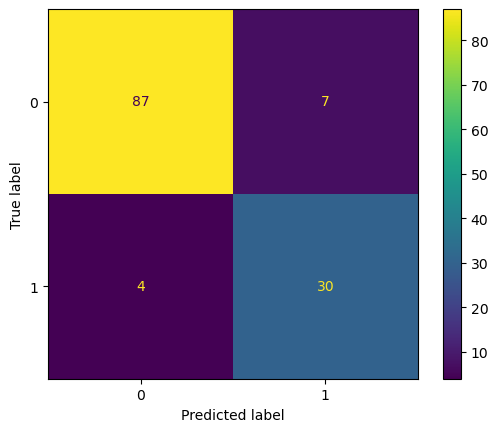

In [38]:
gb=GaussianNB(var_smoothing=1e-09)
gb.fit(x_train,y_train)
y_preds=gb.predict(x_test)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
nbt=accuracy_score(y_test,y_preds)*100
y_tpred2=gb.predict(x_train)
nbtt=accuracy_score(y_tpred2,y_train)*100

In [39]:
par={'max_depth':['None',10,20,30],'max_features':['auto','sqrt','log2']}
rft=GridSearchCV(rf,par,cv=10,scoring='accuracy')
rft.fit(x_train,y_train)
print(rft.best_params_)

{'max_depth': 10, 'max_features': 'sqrt'}


Test accuracy: 0.9296875
train accuracy: 0.9669117647058824
CR:               precision    recall  f1-score   support

           0       0.97      0.94      0.95        94
           1       0.84      0.91      0.87        34

    accuracy                           0.93       128
   macro avg       0.90      0.92      0.91       128
weighted avg       0.93      0.93      0.93       128



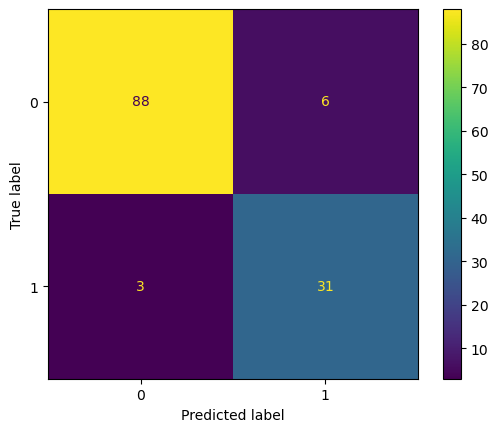

In [40]:
rf=RandomForestClassifier(max_depth=8,max_features='sqrt',min_samples_leaf=3,class_weight='balanced_subsample',random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
rft=accuracy_score(y_test,y_pred)*100
y_tpred3=rf.predict(x_train)
rftt=accuracy_score(y_tpred3,y_train)*100

In [41]:
par={'n_estimators':[50,100,150],'learning_rate':[0.01,0.1,1.0]}
adt=GridSearchCV(adaboost,par,cv=10,scoring='accuracy')
adt.fit(x_train,y_train)
print(adt.best_params_)

{'learning_rate': 1.0, 'n_estimators': 150}


Test accuracy: 0.921875
train accuracy: 0.9816176470588235
CR:               precision    recall  f1-score   support

           0       0.96      0.94      0.95        94
           1       0.83      0.88      0.86        34

    accuracy                           0.92       128
   macro avg       0.89      0.91      0.90       128
weighted avg       0.92      0.92      0.92       128



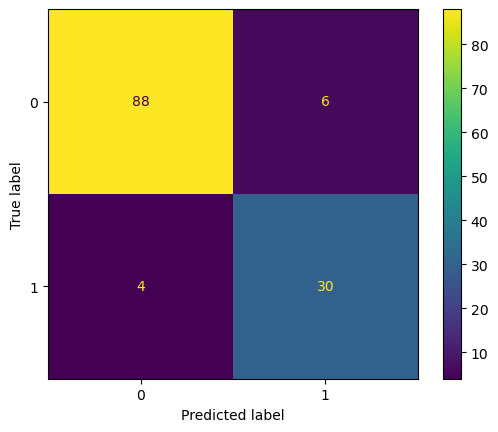

In [42]:
adaboost=AdaBoostClassifier(n_estimators=100,learning_rate=1.0)
adaboost.fit(x_train,y_train)
y_pred=adaboost.predict(x_test)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print('CR:',classification_report(y_test,y_pred))
adt=accuracy_score(y_test,y_pred)*100
y_tpred4=adaboost.predict(x_train)
adtt=accuracy_score(y_tpred4,y_train)*100

In [43]:
par={'n_estimators':[100,200],'max_depth':[3,4,5]}
gbt=GridSearchCV(gbc,par,cv=10,scoring='accuracy')
gbt.fit(x_train,y_train)
print(gbt.best_params_)

{'max_depth': 3, 'n_estimators': 200}


Test accuracy: 0.921875
train accuracy: 0.9926470588235294
CR:               precision    recall  f1-score   support

           0       0.96      0.94      0.95        94
           1       0.83      0.88      0.86        34

    accuracy                           0.92       128
   macro avg       0.89      0.91      0.90       128
weighted avg       0.92      0.92      0.92       128



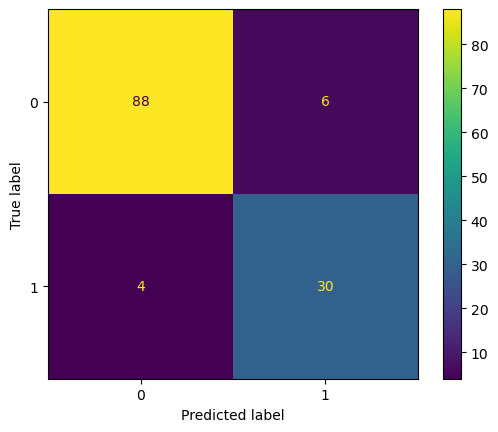

In [44]:
gbc=GradientBoostingClassifier(n_estimators=100,max_depth=3,learning_rate=0.05,random_state=42,subsample=0.9)
gbc.fit(x_train,y_train)
y_preds=gbc.predict(x_test)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_preds))
print('CR:',classification_report(y_test,y_preds))
gbt=accuracy_score(y_test,y_preds)*100
y_tpred4=gbc.predict(x_train)
gbtt=accuracy_score(y_tpred4,y_train)*100

In [45]:
par={'max_depth':[3,5,10],'criterion':['gini','entropy']}
dtt=GridSearchCV(dt,par,cv=10,scoring='accuracy')
dtt.fit(x_train,y_train)
print(dtt.best_params_)

{'criterion': 'entropy', 'max_depth': 3}


Test accuracy: 0.9140625
train accuracy: 0.9595588235294118
CR:               precision    recall  f1-score   support

           0       0.96      0.93      0.94        94
           1       0.81      0.88      0.85        34

    accuracy                           0.91       128
   macro avg       0.88      0.90      0.89       128
weighted avg       0.92      0.91      0.92       128



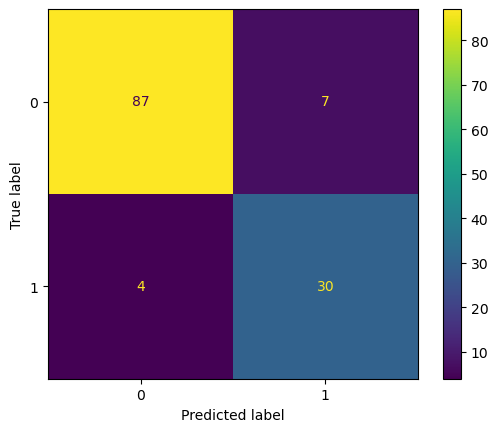

In [46]:
dt=DecisionTreeClassifier(criterion='entropy',max_depth=3)
dt.fit(x_train,y_train)
y_predd=dt.predict(x_test)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_predd))
print('CR:',classification_report(y_test,y_predd))
dtt=accuracy_score(y_test,y_predd)*100
y_tpred5=dt.predict(x_train)
dtt=accuracy_score(y_tpred5,y_train)*100

## Initial Accuracy and Accuracy After HyperParameter Tuning

In [47]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt'])
tb['accuracy']=pd.Series([kc,lra,nb,rfa,ac,gbca,dta])
tb['Accuracy hyperparameter']=pd.Series([knt,lrt,nbt,rft,adt,gbt,dtt])
tb

,model,accuracy,Accuracy hyperparameter
0,knn,92.96875,96.093750
1,lr,92.96875,96.093750
2,gb,91.40625,91.406250
3,rf,93.75000,92.968750
4,adaboost,92.18750,92.187500
5,gbc,92.96875,92.187500
6,dt,92.18750,95.955882


## TEST AND TRAIN ACCURACY

In [48]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt'])
tb['accuracy']=pd.Series([kc,lra,nb,rfa,ac,gbca,dta])
tb

,model,accuracy
0,knn,92.96875
1,lr,92.96875
2,gb,91.40625
3,rf,93.75000
4,adaboost,92.18750
5,gbc,92.96875
6,dt,92.18750


In [49]:
tb1=pd.DataFrame()
tb1['model']=pd.Series(['knn','lr','gb','rf','adaboost','gbc','dt'])
tb1['Test Accuracy']=pd.Series([kntt,lrtt,nbtt,rftt,adtt,gbtt,dtt])
tb1['Train Accuracy']=pd.Series([knt,lrt,nbt,rft,adt,gbt,dtt])
tb1

,model,Test Accuracy,Train Accuracy
0,knn,94.117647,96.093750
1,lr,95.220588,96.093750
2,gb,91.911765,91.406250
3,rf,96.691176,92.968750
4,adaboost,98.161765,92.187500
5,gbc,99.264706,92.187500
6,dt,95.955882,95.955882


## Accuracy Score & Classification Report

In [52]:
for name, model in [("RandomForest", rf), ("GradientBoosting", gbc)]:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)*100
    print(f"\n{name} Test Accuracy: {acc:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))



RandomForest Test Accuracy: 93.75%
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96        94
           1       0.86      0.91      0.89        34

    accuracy                           0.94       128
   macro avg       0.91      0.93      0.92       128
weighted avg       0.94      0.94      0.94       128


GradientBoosting Test Accuracy: 92.19%
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        94
           1       0.83      0.88      0.86        34

    accuracy                           0.92       128
   macro avg       0.89      0.91      0.90       128
weighted avg       0.92      0.92      0.92       128



## Confusion Matrix

#### The confusion matrix indicates that the model correctly classified 94% of students overall. It achieved high recall (88%), showing strong ability to identify students who were admitted, and precision (83%), indicating few false admissions. Only 10 total misclassifications occurred out of 128 samples, demonstrating good generalization and balanced performance.

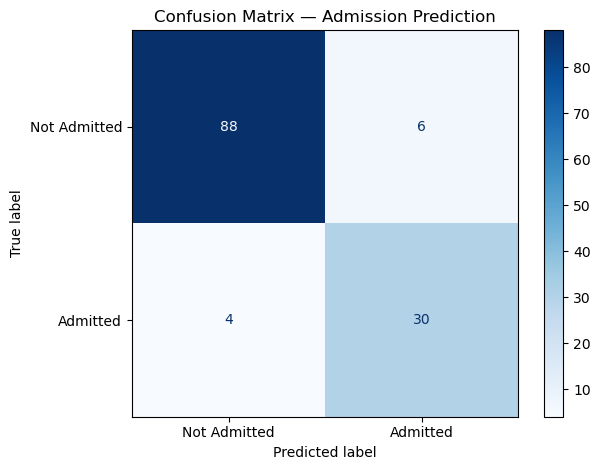

In [79]:
# predict on the test set (not on X_new)
y_pred = model.predict(x_test)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Not Admitted", "Admitted"],
    cmap="Blues", xticks_rotation=0
)
plt.title("Confusion Matrix — Admission Prediction")
plt.tight_layout(); plt.show()

## ROC & AUC

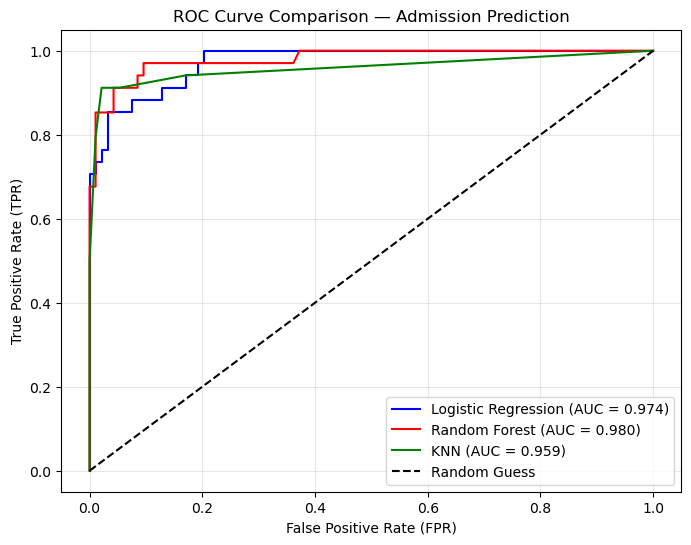

In [72]:
# prob for class 1 = Admitted
logistic_probs = lr.predict_proba(x_test)[:, 1]
rf_probs       = rf.predict_proba(x_test)[:, 1]
knn_probs      = knn.predict_proba(x_test)[:, 1]

# ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_probs)
fpr_rf,        tpr_rf,        _ = roc_curve(y_test, rf_probs)
fpr_knn,       tpr_knn,       _ = roc_curve(y_test, knn_probs)

# AUCs (use roc_auc_score to avoid name clash)
auc_logistic = roc_auc_score(y_test, logistic_probs)
auc_rf       = roc_auc_score(y_test, rf_probs)
auc_knn      = roc_auc_score(y_test, knn_probs)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_logistic, tpr_logistic, label=f'Logistic Regression (AUC = {auc_logistic:.3f})', color='blue')
plt.plot(fpr_rf,        tpr_rf,        label=f'Random Forest (AUC = {auc_rf:.3f})',          color='red')
plt.plot(fpr_knn,       tpr_knn,       label=f'KNN (AUC = {auc_knn:.3f})',                   color='green')

plt.plot([0,1],[0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison — Admission Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Predict

In [56]:
X_new = np.array([
    [330, 115, 5, 5.0, 5.0, 9.8, 1],
    [300, 100, 3, 3.5, 3.0, 8.0, 0]
])

# Predict (0 = No, 1 = Yes)
y_pred = rf.predict(X_new)

# Convert to readable labels
labels = np.where(y_pred == 1, "Admitted ✅", "Not Admitted ❌")

for i, result in enumerate(labels):
    print(f"Student {i+1}: {result}")

Student 1: Admitted ✅
Student 2: Not Admitted ❌


## Save

In [ ]:
import joblib
joblib.dump(model,'model.pkl')